In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#load the data
df= pd.read_csv('../data/processed_data.csv')
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset contains 22544 rows and 41 columns.


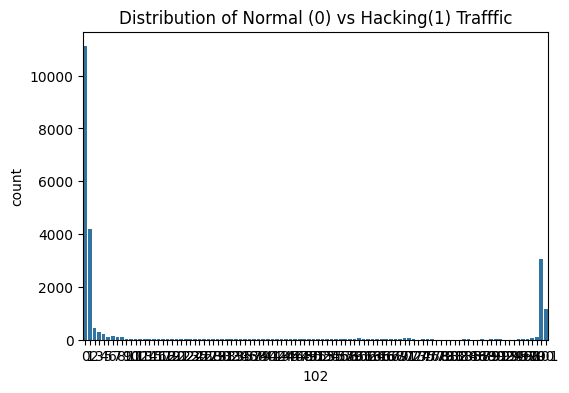

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x=df.columns[-1], data=df)
plt.title('Distribution of Normal (0) vs Hacking(1) Trafffic')
plt.show()

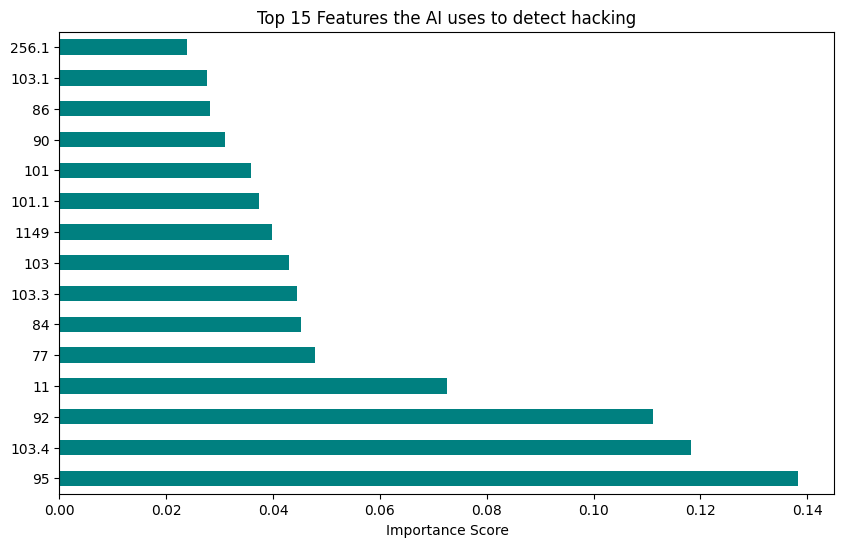

In [7]:
import pickle

with open('../models/nids_model.pkl','rb') as f:
    model = pickle.load(f)

feature_names = df.columns[:-1]

importance = model.feature_importances_

feat_importances = pd.Series(importance, index= feature_names)

plt.figure(figsize=(10,6))
feat_importances.nlargest(15).plot(kind='barh',color='teal')

plt.title('Top 15 Features the AI uses to detect hacking')
plt.xlabel('Importance Score')
plt.show()

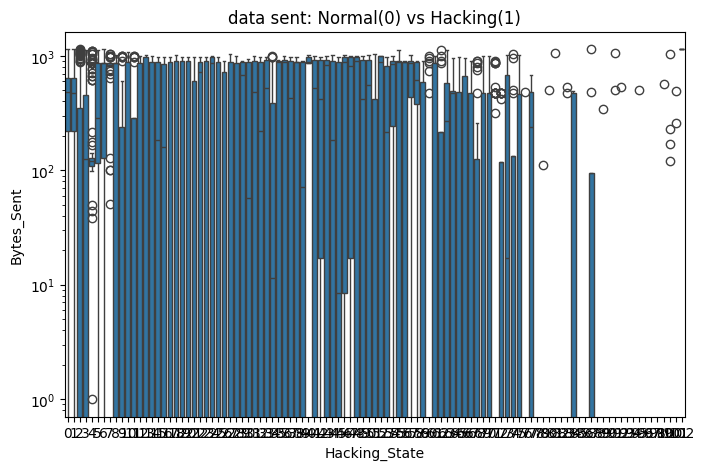

In [8]:
df = pd.read_csv('../data/processed_data.csv', header =None)

plot_data=pd.DataFrame({
    'Hacking_State':df.iloc[:,-1],
    'Bytes_Sent':df.iloc[:,4]
})

plt.figure(figsize=(8,5))
sns.boxplot(x='Hacking_State',y='Bytes_Sent',data=plot_data)
plt.yscale('log')

plt.title('data sent: Normal(0) vs Hacking(1)')
plt.show()